<a href="https://colab.research.google.com/github/MustafaSBny/CSC108-Movie-Project/blob/main/Initial_Project_Google_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSC108 – Initial Project Notebook
## Predicting Box Office Success Using Movie Data
### Mustafa Bukhari

In this project, I analyze a movie metadata dataset to explore which factors help predict whether a movie becomes a box-office success. The goal is to clean the dataset, examine variables such as budget, revenue, runtime, popularity, and genre, and create visualizations to discover trends.
Using methods introduced in CSC108, I build a simple classification model that predicts whether a movie is a “hit” or “non-hit” based on its characteristics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (already uploaded)
df = pd.read_csv('/content/movies_metadata.csv', low_memory=False)

df.head()


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [2]:
# Convert budget & revenue to numeric (some entries are strings)
df['budget'] = pd.to_numeric(df['budget'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['runtime'] = pd.to_numeric(df['runtime'], errors='coerce')
df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce')

# Filter out movies with unrealistic values
df_clean = df[(df['budget'] > 1000) & (df['revenue'] > 1000)]

df_clean[['budget','revenue','runtime','popularity']].describe()


,budget,revenue,runtime,popularity
count,5.312000e+03,5.312000e+03,5311.000000,5312.000000
mean,3.148126e+07,9.145629e+07,109.937677,9.862236
std,4.027580e+07,1.669076e+08,21.997108,13.881930
min,2.500000e+03,1.404000e+03,0.000000,0.000657
25%,5.900000e+06,7.545185e+06,95.000000,5.550277
50%,1.700000e+07,3.051161e+07,106.000000,8.441440
75%,4.000000e+07,1.005295e+08,120.000000,11.787047
max,3.800000e+08,2.787965e+09,338.000000,547.488298


In [3]:
df_clean['hit'] = (df_clean['revenue'] >= 100_000_000).astype(int)

df_clean['hit'].value_counts()

/tmp/ipython-input-538108600.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['hit'] = (df_clean['revenue'] >= 100_000_000).astype(int)


,count
hit,
0,3968
1,1344


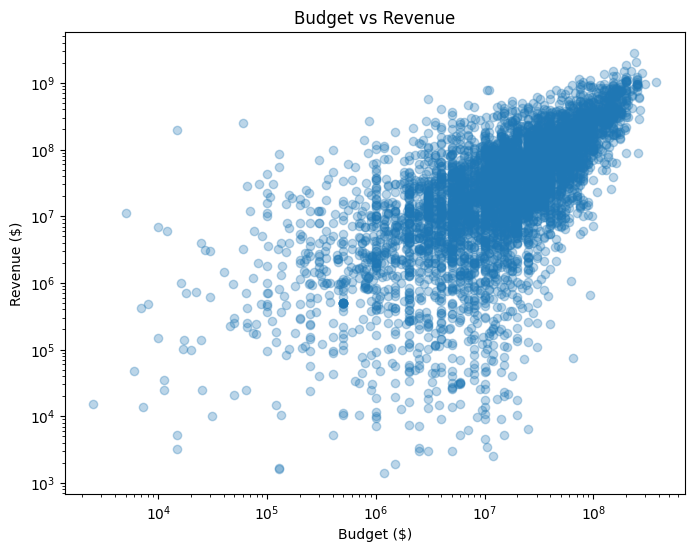

In [4]:
plt.figure(figsize=(8,6))
plt.scatter(df_clean['budget'], df_clean['revenue'], alpha=0.3)
plt.xlabel("Budget ($)")
plt.ylabel("Revenue ($)")
plt.title("Budget vs Revenue")
plt.xscale('log')
plt.yscale('log')
plt.show()

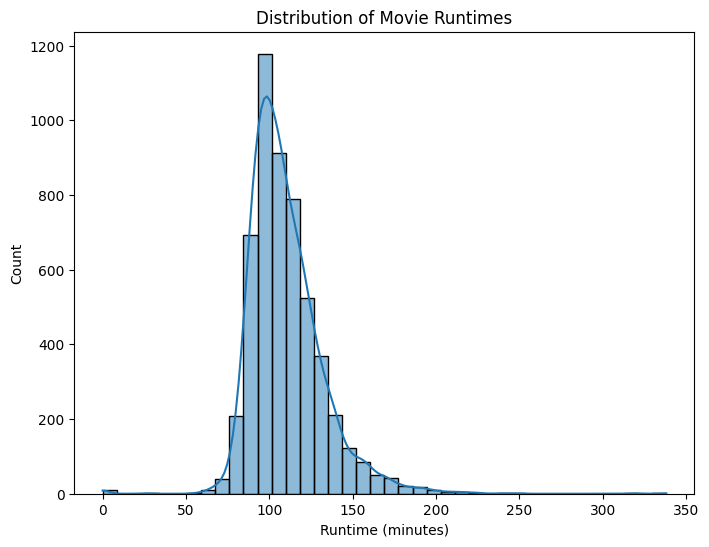

In [5]:
plt.figure(figsize=(8,6))
sns.histplot(df_clean['runtime'], bins=40, kde=True)
plt.xlabel("Runtime (minutes)")
plt.title("Distribution of Movie Runtimes")
plt.show()

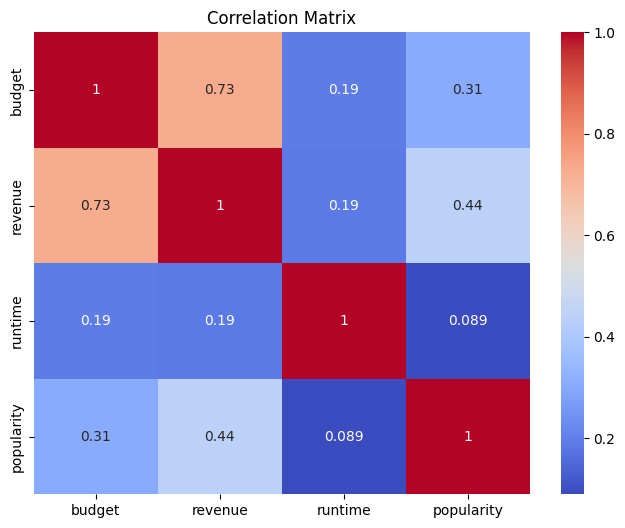

In [6]:
features = ['budget','revenue','runtime','popularity']
plt.figure(figsize=(8,6))
sns.heatmap(df_clean[features].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Findings from EDA

- Higher-budget movies tend to generate higher revenue, though the relationship has significant variance.

- Runtime shows weak correlation with revenue — long movies are not necessarily more successful.

- Popularity has a moderate positive relationship with revenue.

- Revenue distribution is extremely skewed, with a small number of films earning enormous totals.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Select features
X = df_clean[['budget', 'runtime', 'popularity']].fillna(0)
y = df_clean['hit']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8306148055207027
Confusion Matrix:
[[1112   83]
 [ 187  212]]


**Discussion**

The initial model achieves reasonable accuracy given the simplicity of the dataset. Budget and popularity are strong predictors of box-office success, aligning with industry expectations. Runtime appears to have minimal predictive value.

**Limitations**

- The dataset contains missing, zero, or incorrect values for many movies.

- Genre is stored as a JSON-like string and needs deeper parsing to be used effectively.

- The dataset lacks marketing data, release timing, and actor information, which are strong predictors.

**Future Work**

- Parse genre and production company fields.

- Test additional models such as decision trees and random forests.

- Create more sophisticated features (budget-to-revenue ratio, decade, inflation-adjusted revenue).

### GitHub Repository
https://github.com/MustafaSBny/CSC108-Movie-Project